# Qwen3-4B SFT Training Notebook
This notebook prepares SFT data, verifies the environment, trains a LoRA adapter with TRL, and saves training plots as PNG files.

Important: run this notebook with the project `.venv` kernel or execute the Python scripts directly if notebook CUDA import issues occur.

In [1]:
import sys
from pathlib import Path
CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('repo_root', ROOT)

repo_root /local/mnt/workspace/ddudhat/finals


In [2]:
import sys
print(sys.executable)

/root/.cache/uv/builds-v0/.tmpVgrycx/bin/python


In [3]:
# Install / verify packages
packages = [
    "torch>=2.9.0",
    "transformers>=5.6.0",
    "datasets>=4.8.0",
    "trl==1.2.0",
    "peft>=0.19.0",
    "accelerate>=1.13.0",
    "matplotlib>=3.8.0",
    "jupyter>=1.1.0",
    "nbconvert>=7.16.0",
    "nbformat>=5.10.0",
]
print("Install with:")
print("uv pip install --python .venv/bin/python " + " ".join(repr(p) for p in packages))

Install with:
uv pip install --python .venv/bin/python 'torch>=2.9.0' 'transformers>=5.6.0' 'datasets>=4.8.0' 'trl==1.2.0' 'peft>=0.19.0' 'accelerate>=1.13.0' 'matplotlib>=3.8.0' 'jupyter>=1.1.0' 'nbconvert>=7.16.0' 'nbformat>=5.10.0'


In [4]:
import json
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from trl import SFTTrainer
print("torch", torch.__version__, "cuda", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

torch 2.8.0+cu128 cuda True
NVIDIA A100-SXM4-80GB


In [5]:
import json
from pathlib import Path

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
EPISODES_DIR = ROOT / "data" / "tasks" / "robust_episodes"
GROUND_TRUTH = json.loads((ROOT / "data" / "jira_outlook_robust_case.json").read_text())
OUT_PATH = ROOT / "data" / "training" / "sft_train.jsonl"
SYSTEM_PROMPT = (
    "You are a careful ticket triage agent working in a constrained tool-use environment. "
    "Use only the provided Jira and Outlook tools. Return exactly one JSON action."
)
GT_BY_ID = {r["ticket_number"]: r for r in GROUND_TRUTH["jira_records"]}
KEY_PHRASES = [
    "IllegalStateException", "NotificationPreferenceAssembler", "empty locale map", "profile hydration",
    "duplicate redemption", "ledger_event_id", "certificate thumbprint", "invoice footer",
    "template revision", "sample output", "acknowledgement template", "renderer fallback",
    "locale fallback", "tax rounding mismatch", "currency switch", "digest notifications", "timezone migration",
]

def query_variants(logs):
    matched = [phrase for phrase in KEY_PHRASES if phrase.lower() in logs.lower()]
    variants = []
    if matched:
        variants.append(' '.join(matched[:4]))
        variants.append(' '.join(matched[:2]))
    words = logs.split()
    variants.append(' '.join(words[:12]))
    variants.append(' '.join(words[12:24]))
    deduped = []
    for item in variants:
        item = ' '.join(item.split())
        if item and item not in deduped:
            deduped.append(item)
    return deduped

def msg_example(obs, action):
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": json.dumps(obs, indent=2)},
            {"role": "assistant", "content": json.dumps(action, ensure_ascii=False)},
        ]
    }

examples = []
for path in sorted(EPISODES_DIR.glob('*.json')):
    task = json.loads(path.read_text())
    ticket = task['assigned_ticket_number']
    gt = GT_BY_ID[ticket]
    assigned = next(r for r in task['jira_records'] if r['ticket_number'] == ticket)
    obs0 = {
        'task_id': task['task_id'],
        'assigned_ticket_number': ticket,
        'objective': task['objective'],
        'steps_taken': 0,
        'assigned_ticket': assigned,
        'history': [],
    }
    path_nodes = gt.get('ground_truth_path', [])
    resolution = gt.get('resolution')
    resolution_notes = gt.get('resolution_notes')
    searches = query_variants(gt['logs'])
    if resolution == 'duplicate' and path_nodes:
        canonical = path_nodes[-1]
        for q in searches[:2]:
            examples.append(msg_example(obs0, {'tool': 'search_jira', 'query': q}))
        hist = [{'action': {'tool': 'search_jira', 'query': searches[0]}, 'result_hint': f'Finds canonical or bridge evidence for {ticket}'}]
        obs1 = {**obs0, 'steps_taken': 1, 'history': hist}
        examples.append(msg_example(obs1, {'tool': 'get_jira_ticket', 'ticket_number': canonical}))
        obs2 = {**obs0, 'steps_taken': 2, 'history': hist + [{'action': {'tool': 'get_jira_ticket', 'ticket_number': canonical}, 'result_hint': f'Reveals closed canonical Jira {canonical}'}]}
        examples.append(msg_example(obs2, {'tool': 'submit_resolution', 'ticket_number': ticket, 'resolution': 'duplicate', 'resolution_notes': resolution_notes}))
    elif resolution == 'needs_more_info':
        for q in searches[:2]:
            examples.append(msg_example(obs0, {'tool': 'search_outlook', 'query': q}))
        hist = [{'action': {'tool': 'search_outlook', 'query': searches[0]}, 'result_hint': f'Finds missing-information thread for {ticket}'}]
        obs1 = {**obs0, 'steps_taken': 1, 'history': hist}
        examples.append(msg_example(obs1, {'tool': 'submit_resolution', 'ticket_number': ticket, 'resolution': 'needs_more_info'}))
    else:
        for q in searches[:3]:
            examples.append(msg_example(obs0, {'tool': 'search_jira', 'query': q}))

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUT_PATH.write_text(''.join(json.dumps(item) + "\n" for item in examples))
print(f'wrote {len(examples)} examples to {OUT_PATH}')

wrote 75 examples to /local/mnt/workspace/ddudhat/finals/data/training/sft_train.jsonl


In [6]:
dataset = load_dataset("json", data_files=str(ROOT / "data" / "training" / "sft_train.jsonl"), split="train")
print(dataset)
print(dataset[0])

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 75
})
{'messages': [{'role': 'system', 'content': 'You are a careful ticket triage agent working in a constrained tool-use environment. Use only the provided Jira and Outlook tools. Return exactly one JSON action.'}, {'role': 'user', 'content': '{\n  "task_id": "robust_jira_2090",\n  "assigned_ticket_number": "JIRA-2090",\n  "objective": "Investigate the assigned Jira ticket and submit the correct resolution using Jira and Outlook evidence.",\n  "steps_taken": 0,\n  "assigned_ticket": {\n    "ticket_number": "JIRA-2090",\n    "assignee": "deepa.nair",\n    "logs": "Build 2026.05.6 checkout service showed intermittent tax rounding mismatch when cart currency switched from JPY to USD mid-session. Logs mention stale currency context and cache carryover from previous quote computation. Support saw the mismatch only after account locale changed and cart totals were recalculated from an old quote snapshot.",\n    "date": "2026-05-13",\n    

In [7]:
def format_example(example):
    parts = []
    for msg in example["messages"]:
        parts.append(f"<|im_start|>{msg['role']}\n{msg['content']}<|im_end|>")
    return {"text": "\n".join(parts)}

formatted = dataset.map(format_example)
print(formatted[0]["text"][:800])

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

<|im_start|>system
You are a careful ticket triage agent working in a constrained tool-use environment. Use only the provided Jira and Outlook tools. Return exactly one JSON action.<|im_end|>
<|im_start|>user
{
  "task_id": "robust_jira_2090",
  "assigned_ticket_number": "JIRA-2090",
  "objective": "Investigate the assigned Jira ticket and submit the correct resolution using Jira and Outlook evidence.",
  "steps_taken": 0,
  "assigned_ticket": {
    "ticket_number": "JIRA-2090",
    "assignee": "deepa.nair",
    "logs": "Build 2026.05.6 checkout service showed intermittent tax rounding mismatch when cart currency switched from JPY to USD mid-session. Logs mention stale currency context and cache carryover from previous quote computation. Support saw the mismatch only after account locale c


In [8]:
MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
OUTPUT_DIR = "training/output/qwen3_4b_sft_notebook"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3.0,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    logging_steps=1,
    save_steps=100,
    bf16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=formatted,
    processing_class=tokenizer,
    peft_config=peft_config,
    formatting_func=lambda ex: ex["text"],
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Applying formatting function to train dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/75 [00:00<?, ? examples/s]

In [9]:
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(train_result)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,3.151918
2,2.718110
3,2.251777
4,2.194309
5,1.954825
6,1.788664
7,1.569022
8,1.455340
9,1.355816
10,1.270895


TrainOutput(global_step=15, training_loss=1.6803016821543375, metrics={'train_runtime': 66.623, 'train_samples_per_second': 3.377, 'train_steps_per_second': 0.225, 'total_flos': 1652253857510400.0, 'train_loss': 1.6803016821543375})


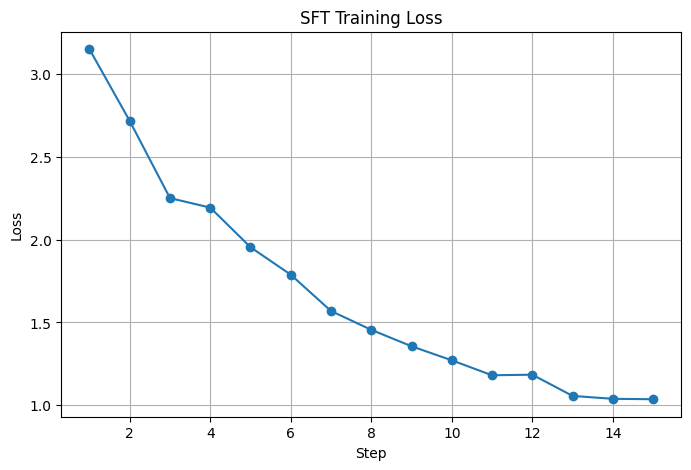

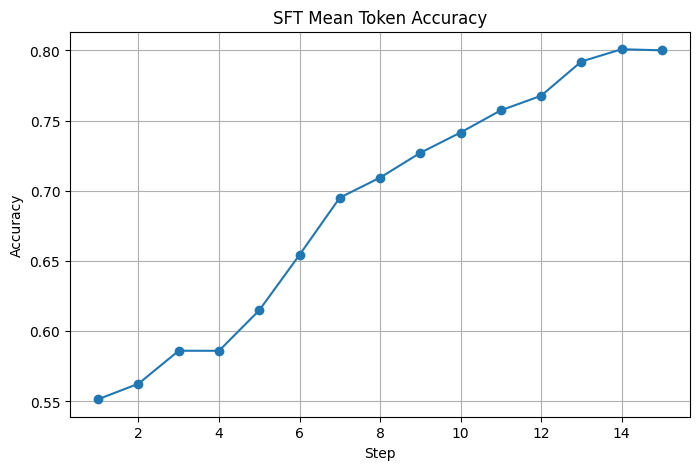

Saved: /local/mnt/workspace/ddudhat/finals/training/plots/sft_loss_curve.png
Saved: /local/mnt/workspace/ddudhat/finals/training/plots/sft_accuracy_curve.png


In [10]:
from pathlib import Path
output_root = Path(OUTPUT_DIR)
state_candidates = sorted(output_root.glob("checkpoint-*/trainer_state.json"))
state_path = state_candidates[-1] if state_candidates else output_root / "trainer_state.json"
state = json.loads(state_path.read_text())
logs = [entry for entry in state["log_history"] if "loss" in entry]
steps = [entry["step"] for entry in logs]
losses = [entry["loss"] for entry in logs]
accs = [entry.get("mean_token_accuracy") for entry in logs]

plot_dir = ROOT / "training" / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker="o")
plt.title("SFT Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
loss_png = plot_dir / "sft_loss_curve.png"
plt.savefig(loss_png, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(steps, accs, marker="o")
plt.title("SFT Mean Token Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.grid(True)
acc_png = plot_dir / "sft_accuracy_curve.png"
plt.savefig(acc_png, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", loss_png)
print("Saved:", acc_png)

In [11]:
from peft import PeftModel
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype="auto", device_map="auto")
model = PeftModel.from_pretrained(base, OUTPUT_DIR)
prompt = """<|im_start|>system
You are a careful ticket triage agent working in a constrained tool-use environment. Use only the provided Jira and Outlook tools. Return exactly one JSON action.<|im_end|>
<|im_start|>user
{"task_id":"robust_jira_2104","assigned_ticket_number":"JIRA-2104","objective":"Investigate the assigned Jira ticket and submit the correct resolution using Jira and Outlook evidence.","steps_taken":0,"assigned_ticket":{"ticket_number":"JIRA-2104","assignee":"nisha.patel","logs":"Build 2026.05.7 failed during post-deploy validation in the notification preference sync flow. Service logs show IllegalStateException when NotificationPreferenceAssembler processes an empty locale map after profile hydration retry.","date":"2026-05-18","build_number":"2026.05.7","resolution":"unresolved","status":"open","resolution_notes":null},"history":[]}<|im_end|>
<|im_start|>assistant
"""
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
out = model.generate(**inputs, max_new_tokens=80, do_sample=False)
print(tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{"tool": "search_jira", "query": "notification preference sync"}


# RL Post-Training (PPO-compatible fallback)
This section starts from the SFT adapter and runs RL-style post-training inside the environment. If TRL PPO APIs are unavailable in the current install, the notebook falls back to a lightweight policy-gradient loop so the workflow still runs and produces reward/loss plots.

In [ ]:
import asyncio
import json
import subprocess
import time
from pathlib import Path

import torch
import torch.nn.functional as F
from peft import PeftModel

from client import JiraOutlookEnv
from models import JiraOutlookAction

PPO_OUTPUT_DIR = ROOT / "training" / "output" / "qwen3_4b_ppo_notebook"
PPO_PLOT_DIR = ROOT / "training" / "plots"
PPO_PLOT_DIR.mkdir(parents=True, exist_ok=True)
PPO_STEPS = 6
PPO_EPISODES = 6
USE_TRL_PPO = False
try:
    from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead
    USE_TRL_PPO = True
except Exception as exc:
    print("TRL PPO APIs unavailable; falling back to lightweight RL loop:", exc)


In [ ]:
import socket

server_process = subprocess.Popen([sys.executable, "-m", "server.app"], cwd=str(ROOT), stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
for _ in range(30):
    try:
        with socket.create_connection(("127.0.0.1", 8000), timeout=1):
            break
    except OSError:
        time.sleep(1)
else:
    raise RuntimeError("server did not start on 127.0.0.1:8000")
print("server_pid", server_process.pid)

In [ ]:
def load_ppo_policy(base_model_name: str, adapter_path: Path):
    base_model = AutoModelForCausalLM.from_pretrained(base_model_name, torch_dtype="auto", device_map="auto")
    peft_model = PeftModel.from_pretrained(base_model, str(adapter_path))
    ppo_tokenizer = AutoTokenizer.from_pretrained(str(adapter_path), use_fast=True)
    if ppo_tokenizer.pad_token is None:
        ppo_tokenizer.pad_token = ppo_tokenizer.eos_token
    if USE_TRL_PPO:
        value_model = AutoModelForCausalLMWithValueHead.from_pretrained(peft_model)
        return value_model, ppo_tokenizer
    return peft_model, ppo_tokenizer

def build_ppo_prompt(observation):
    payload = {
        "instructions": [
            "Return exactly one JSON action.",
            "Use only get_jira_ticket, search_jira, get_outlook_mail, search_outlook, submit_resolution.",
            "If submitting duplicate, include the canonical Jira id in resolution_notes.",
        ],
        "observation": observation,
    }
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{json.dumps(payload, indent=2)}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

def parse_ppo_action(text: str) -> JiraOutlookAction:
    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1:
        raise ValueError(f"No JSON action in: {text}")
    return JiraOutlookAction(**json.loads(text[start:end + 1]))

def compute_response_logprob(model, tokenizer, prompt: str, response: str):
    full_text = prompt + response
    tokens = tokenizer(full_text, return_tensors="pt").to(model.device if hasattr(model, "device") else model.pretrained_model.device)
    prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    prompt_len = prompt_ids.shape[1]
    outputs = model(**tokens)
    logits = outputs.logits[:, :-1, :]
    labels = tokens["input_ids"][:, 1:]
    log_probs = torch.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
    response_start = max(prompt_len - 1, 0)
    response_log_probs = token_log_probs[:, response_start:]
    return response_log_probs.sum()

def generate_action_with_logprob(model, tokenizer, prompt: str):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device if hasattr(model, "device") else model.pretrained_model.device)
    generated = model.generate(**inputs, max_new_tokens=96, do_sample=True, top_p=0.9, temperature=0.7)
    response_ids = generated[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(response_ids, skip_special_tokens=True)
    logprob = compute_response_logprob(model, tokenizer, prompt, response)
    return response, logprob

async def ppo_rollout_episode(env, tokenizer, model, task_id: str, max_steps: int):
    reset = await env.reset(task_id=task_id)
    observation = reset.observation
    prompt_texts, response_texts, rewards, logprobs = [], [], [], []

    for _ in range(max_steps):
        obs_payload = {
            "task": observation.task.model_dump(mode="json") if observation.task else None,
            "assigned_ticket": observation.assigned_ticket.model_dump(mode="json") if observation.assigned_ticket else None,
            "returned_record": observation.returned_record,
            "jira_results": [hit.model_dump(mode="json") for hit in observation.jira_results],
            "outlook_results": [hit.model_dump(mode="json") for hit in observation.outlook_results],
            "reward": observation.reward,
            "done": observation.done,
            "last_action_error": observation.last_action_error,
            "steps_taken": observation.steps_taken,
        }
        prompt = build_ppo_prompt(obs_payload)
        response, logprob = generate_action_with_logprob(model, tokenizer, prompt)
        try:
            action = parse_ppo_action(response)
        except Exception:
            action = JiraOutlookAction(tool="search_jira", query="error", fields=["ticket_number"])
        step = await env.step(action)
        observation = step.observation
        if step.reward is not None:
            observation.reward = step.reward
        if step.done:
            observation.done = True
        prompt_texts.append(prompt)
        response_texts.append(response)
        rewards.append(float(observation.reward or 0.0))
        logprobs.append(logprob)
        if observation.done:
            break

    return prompt_texts, response_texts, rewards, logprobs


In [ ]:
async def run_ppo_training():
    ppo_model, ppo_tokenizer = load_ppo_policy(MODEL_NAME, Path(OUTPUT_DIR))

    task_ids = sorted(p.stem for p in EPISODES_DIR.glob("*.json"))[:PPO_EPISODES]
    env = JiraOutlookEnv(base_url="http://127.0.0.1:8000")
    reward_history = []
    mean_reward_history = []
    policy_loss_history = []

    if USE_TRL_PPO:
        trainer = PPOTrainer(config=PPOConfig(batch_size=4, mini_batch_size=1, learning_rate=1e-5, log_with=None), model=ppo_model, ref_model=None, tokenizer=ppo_tokenizer)
    else:
        optimizer = torch.optim.AdamW(ppo_model.parameters(), lr=1e-6)

    for task_id in task_ids:
        prompts, responses, rewards, logprobs = await ppo_rollout_episode(env, ppo_tokenizer, ppo_model, task_id, PPO_STEPS)
        if not prompts:
            continue
        reward_history.extend(rewards)
        mean_reward_history.append(sum(rewards) / len(rewards))

        if USE_TRL_PPO:
            for start in range(0, len(prompts), 4):
                batch_prompts = prompts[start:start + 4]
                batch_responses = responses[start:start + 4]
                batch_rewards = rewards[start:start + 4]
                if not batch_prompts:
                    continue
                query_tensors = [ppo_tokenizer(prompt, return_tensors="pt")["input_ids"][0].to(ppo_model.pretrained_model.device) for prompt in batch_prompts]
                response_tensors = [ppo_tokenizer(resp, return_tensors="pt")["input_ids"][0].to(ppo_model.pretrained_model.device) for resp in batch_responses]
                reward_tensors = [torch.tensor(reward, device=ppo_model.pretrained_model.device) for reward in batch_rewards]
                trainer.config.batch_size = len(query_tensors)
                stats = trainer.step(query_tensors, response_tensors, reward_tensors)
                loss_value = float(stats.get("ppo/loss/total", 0.0)) if isinstance(stats, dict) else 0.0
                policy_loss_history.append(loss_value)
        else:
            returns = torch.tensor(rewards, dtype=torch.float32, device=logprobs[0].device if logprobs else "cpu")
            baseline = returns.mean() if len(returns) else torch.tensor(0.0, device=returns.device)
            advantages = returns - baseline
            if logprobs:
                loss = -(torch.stack(logprobs) * advantages).mean()
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(ppo_model.parameters(), 1.0)
                optimizer.step()
                policy_loss_history.append(float(loss.detach().cpu()))

    await env.close()
    ppo_model.save_pretrained(str(PPO_OUTPUT_DIR))
    ppo_tokenizer.save_pretrained(str(PPO_OUTPUT_DIR))
    return {
        "episodes": len(task_ids),
        "reward_history": reward_history,
        "mean_reward_history": mean_reward_history,
        "policy_loss_history": policy_loss_history,
        "mode": "trl_ppo" if USE_TRL_PPO else "policy_gradient_fallback",
    }

ppo_result = await run_ppo_training()
print(json.dumps({
    "episodes": ppo_result["episodes"],
    "num_rewards": len(ppo_result["reward_history"]),
    "mean_reward": sum(ppo_result["reward_history"]) / len(ppo_result["reward_history"]) if ppo_result["reward_history"] else 0.0,
    "output_dir": str(PPO_OUTPUT_DIR),
    "mode": ppo_result["mode"],
}, indent=2))

In [ ]:
reward_png = PPO_PLOT_DIR / "ppo_reward_curve.png"
mean_reward_png = PPO_PLOT_DIR / "ppo_mean_reward_curve.png"
loss_png = PPO_PLOT_DIR / "ppo_policy_loss_curve.png"

reward_values = ppo_result["reward_history"]
episode_means = ppo_result["mean_reward_history"]
policy_loss_values = ppo_result["policy_loss_history"]
reward_steps = list(range(1, len(reward_values) + 1))
loss_steps = list(range(1, len(policy_loss_values) + 1))

plt.figure(figsize=(8, 5))
plt.plot(reward_steps, reward_values, marker="o")
plt.title("RL Reward per Collected Step")
plt.xlabel("Collected step")
plt.ylabel("Reward")
plt.grid(True)
plt.savefig(reward_png, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(episode_means) + 1), episode_means, marker="o")
plt.title("RL Mean Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Mean reward")
plt.grid(True)
plt.savefig(mean_reward_png, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(loss_steps, policy_loss_values, marker="o")
plt.title("RL Policy Loss")
plt.xlabel("Update step")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(loss_png, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", reward_png)
print("Saved:", mean_reward_png)
print("Saved:", loss_png)
print("RL mode:", ppo_result["mode"])

In [ ]:
server_process.terminate()
server_process.wait(timeout=10)
print("server_stopped")